In [5]:
import torchvision
from torchvision import datasets, transforms

In [6]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

import pandas as pd

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [7]:
from torch.utils.data import DataLoader, TensorDataset, random_split

@dataclass
class DataConfig:
    dataset_name: str = "KMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10" | "DIGITS_FALLBACK"
    data_dir: str = "./data"
    batch_size: int = 128
    val_fraction: float = 0.15
    num_workers: int = 0
    fast_mode: bool = True
    max_train_samples: int = 12000   # используется только в fast_mode для больших датасетов
    max_val_samples: int = 2000
    max_test_samples: int = 3000

In [9]:

def _try_load_torchvision_dataset(cfg: DataConfig):
    """Пытаемся загрузить torchvision-датасет.
    Возвращаем: (train_dataset, test_dataset, input_dim, num_classes, info_str)
    """
    import torchvision
    from torchvision import datasets, transforms



    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])

    train_ds = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=True, download=True, transform=transform)
    test_ds  = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=False, download=True, transform=transform)
    return train_ds, test_ds, 28 * 28, 47, "torchvision.EMNIST(split='balanced') (28x28, 47 классов)"




def load_data(cfg: DataConfig):
    
    train_ds, test_ds, input_dim, num_classes, info = _try_load_torchvision_dataset(cfg)

    val_size = int(len(train_ds) * cfg.val_fraction)
    train_size = len(train_ds) - val_size

    generator = torch.Generator().manual_seed(RANDOM_STATE)
    train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

    def maybe_subsample(ds, max_n: int):
        if not cfg.fast_mode:
            return ds
        if len(ds) <= max_n:
            return ds
        idx = torch.randperm(len(ds), generator=generator)[:max_n]
        return torch.utils.data.Subset(ds, idx.tolist())

    train_split = maybe_subsample(train_split, cfg.max_train_samples)
    val_split   = maybe_subsample(val_split,   cfg.max_val_samples)
    test_ds     = maybe_subsample(test_ds,     cfg.max_test_samples)

    train_loader = DataLoader(train_split, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_split,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader, input_dim, num_classes, info

data_cfg = DataConfig(dataset_name="EMNIST", fast_mode=True)
train_loader, val_loader, test_loader, INPUT_DIM, NUM_CLASSES, DATA_INFO = load_data(data_cfg)

print("Dataset:", DATA_INFO)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))
print("INPUT_DIM:", INPUT_DIM, "| NUM_CLASSES:", NUM_CLASSES)

Dataset: torchvision.EMNIST(split='balanced') (28x28, 47 классов)
Train batches: 94 | Val batches: 16 | Test batches: 24
INPUT_DIM: 784 | NUM_CLASSES: 47


In [10]:
x, y = next(iter(train_loader))
x.shape, y.shape, x.min().item(), x.max().item()

(torch.Size([128, 1, 28, 28]), torch.Size([128]), -1.0, 1.0)

In [11]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [12]:
def unpack_batch(batch):
    x, y = batch
    return x, y

In [13]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [15]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [16]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [17]:

import torch.nn as nn
import torch.optim as optim


epoch 01/20 | train loss=2.5253, acc=0.3436 | val loss=1.6527, acc=0.5442
epoch 02/20 | train loss=1.4886, acc=0.5761 | val loss=1.3876, acc=0.6036
epoch 03/20 | train loss=1.2666, acc=0.6288 | val loss=1.2259, acc=0.6509
epoch 04/20 | train loss=1.1191, acc=0.6750 | val loss=1.1513, acc=0.6609
epoch 05/20 | train loss=1.0104, acc=0.7019 | val loss=1.0536, acc=0.6883
epoch 06/20 | train loss=0.9267, acc=0.7178 | val loss=1.0031, acc=0.6947
epoch 07/20 | train loss=0.8391, acc=0.7407 | val loss=0.9621, acc=0.7184
epoch 08/20 | train loss=0.7702, acc=0.7623 | val loss=0.9233, acc=0.7158
epoch 09/20 | train loss=0.7092, acc=0.7792 | val loss=0.8479, acc=0.7327
epoch 10/20 | train loss=0.6605, acc=0.7934 | val loss=0.8295, acc=0.7519
epoch 11/20 | train loss=0.6154, acc=0.8026 | val loss=0.8365, acc=0.7412
epoch 12/20 | train loss=0.5842, acc=0.8101 | val loss=0.8435, acc=0.7404
epoch 13/20 | train loss=0.5347, acc=0.8260 | val loss=0.7982, acc=0.7566
epoch 14/20 | train loss=0.5005, acc=0

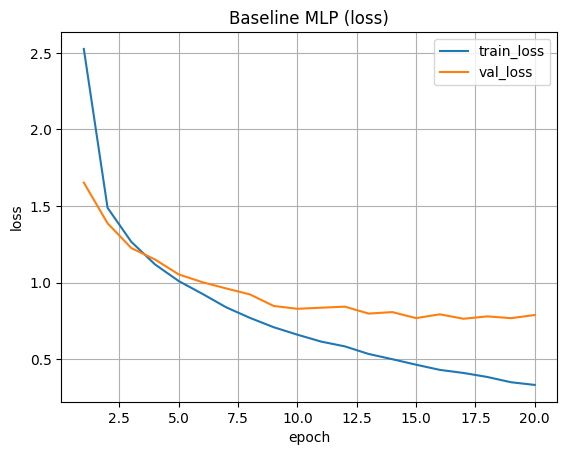

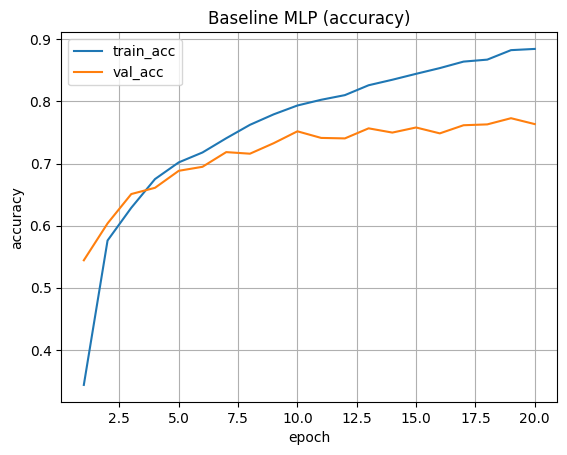

In [18]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(input_dim=INPUT_DIM, num_classes=NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

epoch 01/20 | train loss=2.9824, acc=0.2107 | val loss=1.8461, acc=0.5140
epoch 02/20 | train loss=1.9106, acc=0.4464 | val loss=1.4377, acc=0.6049
epoch 03/20 | train loss=1.6093, acc=0.5321 | val loss=1.2511, acc=0.6346
epoch 04/20 | train loss=1.4424, acc=0.5752 | val loss=1.1458, acc=0.6525
epoch 05/20 | train loss=1.3275, acc=0.6006 | val loss=1.0657, acc=0.6887
epoch 06/20 | train loss=1.2555, acc=0.6235 | val loss=1.0177, acc=0.6931
epoch 07/20 | train loss=1.1893, acc=0.6432 | val loss=0.9598, acc=0.7124
epoch 08/20 | train loss=1.1271, acc=0.6547 | val loss=0.9132, acc=0.7104
epoch 09/20 | train loss=1.0696, acc=0.6662 | val loss=0.8963, acc=0.7200
epoch 10/20 | train loss=1.0424, acc=0.6729 | val loss=0.8590, acc=0.7345
epoch 11/20 | train loss=0.9928, acc=0.6874 | val loss=0.8611, acc=0.7415
epoch 12/20 | train loss=0.9592, acc=0.6938 | val loss=0.8156, acc=0.7400
epoch 13/20 | train loss=0.9396, acc=0.7051 | val loss=0.8075, acc=0.7502
epoch 14/20 | train loss=0.9275, acc=0

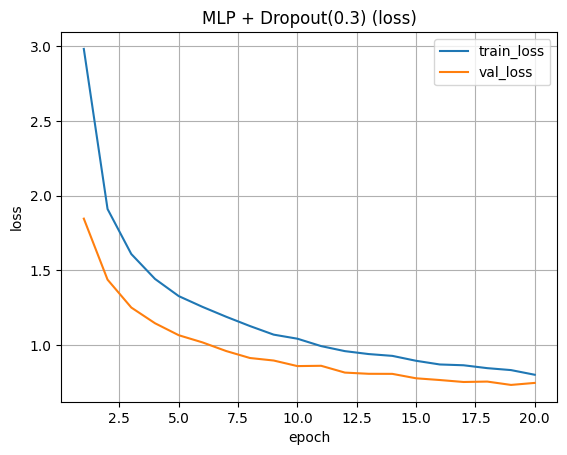

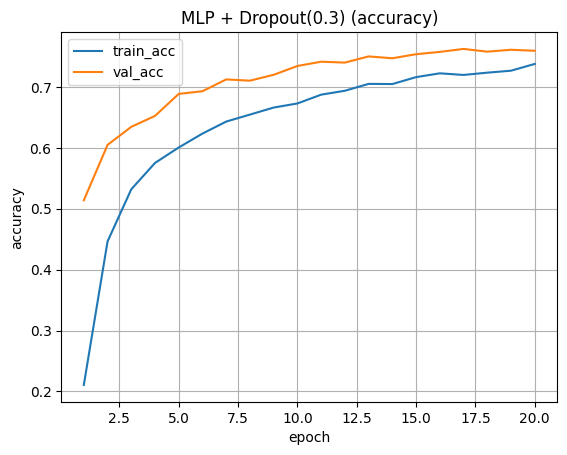

Dropout test: loss=0.8233, acc=0.7542


In [19]:
set_seed(42)
dropout_model = MLP(input_dim=INPUT_DIM, num_classes=NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=2.2612, acc=0.4955 | val loss=1.4783, acc=0.6515
epoch 02/20 | train loss=1.1430, acc=0.7087 | val loss=1.0260, acc=0.7207
epoch 03/20 | train loss=0.7983, acc=0.7762 | val loss=0.8348, acc=0.7568
epoch 04/20 | train loss=0.6152, acc=0.8208 | val loss=0.8061, acc=0.7460
epoch 05/20 | train loss=0.5007, acc=0.8469 | val loss=0.7406, acc=0.7718
epoch 06/20 | train loss=0.4027, acc=0.8779 | val loss=0.7756, acc=0.7502
epoch 07/20 | train loss=0.3440, acc=0.8956 | val loss=0.7574, acc=0.7696
epoch 08/20 | train loss=0.2950, acc=0.9083 | val loss=0.7404, acc=0.7654
epoch 09/20 | train loss=0.2518, acc=0.9210 | val loss=0.7367, acc=0.7738
epoch 10/20 | train loss=0.2220, acc=0.9304 | val loss=0.7465, acc=0.7624
epoch 11/20 | train loss=0.1958, acc=0.9385 | val loss=0.7785, acc=0.7656
epoch 12/20 | train loss=0.1782, acc=0.9425 | val loss=0.8119, acc=0.7625
epoch 13/20 | train loss=0.1586, acc=0.9504 | val loss=0.7436, acc=0.7749
epoch 14/20 | train loss=0.1359, acc=0

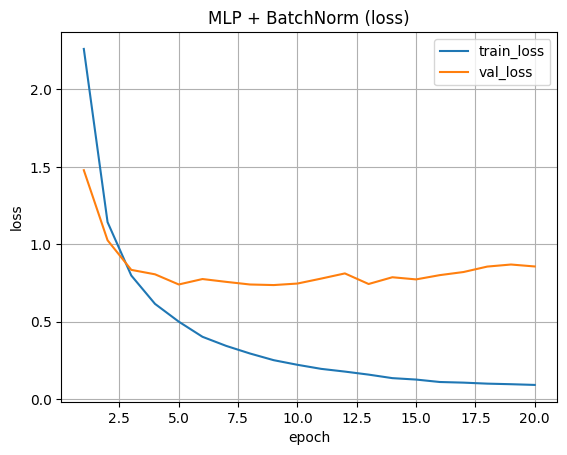

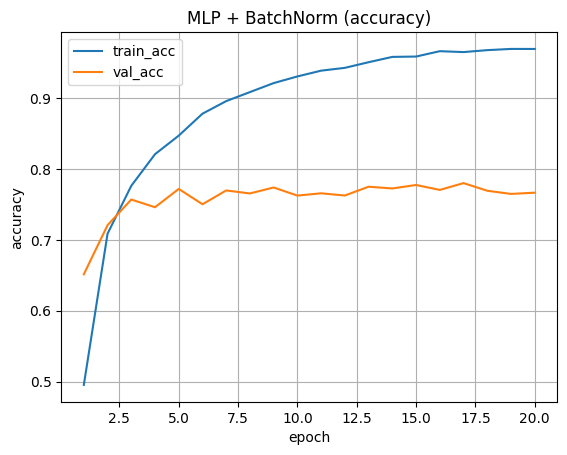

BatchNorm test: loss=0.9714, acc=0.7467


In [20]:
set_seed(42)
bn_model = MLP(input_dim=INPUT_DIM, num_classes=NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [21]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/50 | train loss=2.9824, acc=0.2107 | val loss=1.8461, acc=0.5140
epoch 02/50 | train loss=1.9106, acc=0.4464 | val loss=1.4377, acc=0.6049
epoch 03/50 | train loss=1.6093, acc=0.5321 | val loss=1.2511, acc=0.6346
epoch 04/50 | train loss=1.4424, acc=0.5752 | val loss=1.1458, acc=0.6525
epoch 05/50 | train loss=1.3275, acc=0.6006 | val loss=1.0657, acc=0.6887
epoch 06/50 | train loss=1.2555, acc=0.6235 | val loss=1.0177, acc=0.6931
epoch 07/50 | train loss=1.1893, acc=0.6432 | val loss=0.9598, acc=0.7124
epoch 08/50 | train loss=1.1271, acc=0.6547 | val loss=0.9132, acc=0.7104
epoch 09/50 | train loss=1.0696, acc=0.6662 | val loss=0.8963, acc=0.7200
epoch 10/50 | train loss=1.0424, acc=0.6729 | val loss=0.8590, acc=0.7345
epoch 11/50 | train loss=0.9928, acc=0.6874 | val loss=0.8611, acc=0.7415
epoch 12/50 | train loss=0.9592, acc=0.6938 | val loss=0.8156, acc=0.7400
epoch 13/50 | train loss=0.9396, acc=0.7051 | val loss=0.8075, acc=0.7502
epoch 14/50 | train loss=0.9275, acc=0

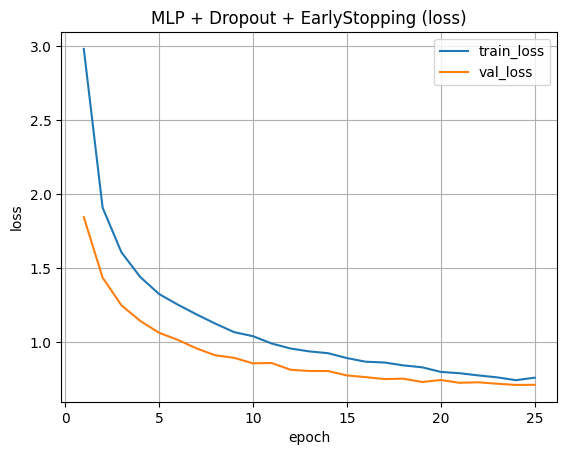

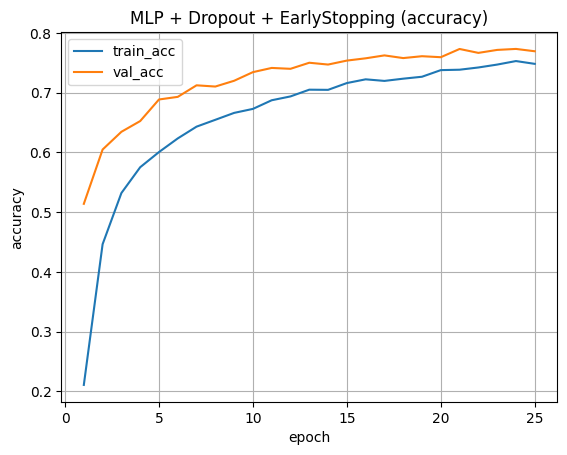

Combo test: loss=0.8044, acc=0.7606


In [22]:
set_seed(42)
combo_model = MLP(input_dim=INPUT_DIM, num_classes=NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [23]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.7480
  dropout: test_acc=0.7542
batchnorm: test_acc=0.7467
    combo: test_acc=0.7606


In [24]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

def make_model():
    return MLP(input_dim=INPUT_DIM, num_classes=NUM_CLASSES, ).to(DEVICE)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")


Experiment LR_high: Adam lr=0.1
epoch 01/6 | train loss=20.1043, acc=0.0195 | val loss=3.8586, acc=0.0244
epoch 02/6 | train loss=3.8649, acc=0.0193 | val loss=3.8603, acc=0.0229
epoch 03/6 | train loss=3.8641, acc=0.0211 | val loss=3.8608, acc=0.0193
epoch 04/6 | train loss=3.8639, acc=0.0180 | val loss=3.8551, acc=0.0226
epoch 05/6 | train loss=3.8618, acc=0.0232 | val loss=3.8578, acc=0.0219
epoch 06/6 | train loss=3.8629, acc=0.0211 | val loss=3.8669, acc=0.0195


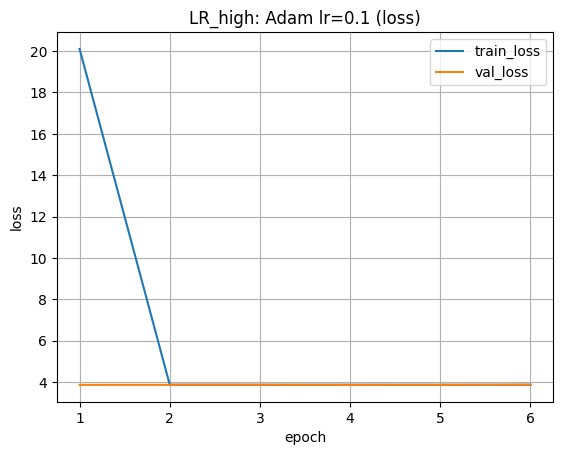

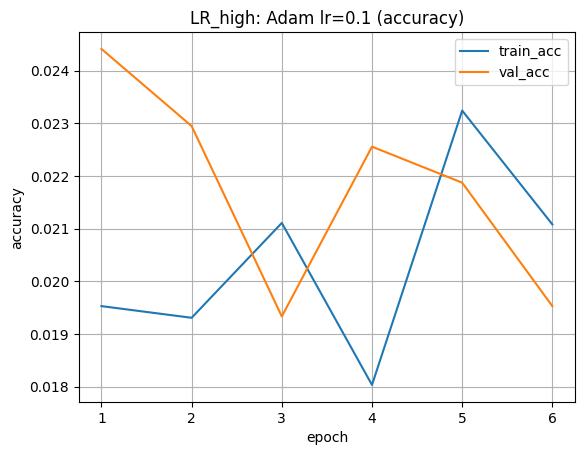


Experiment LR_low: Adam lr=1e-05
epoch 01/6 | train loss=3.8436, acc=0.0303 | val loss=3.8287, acc=0.0455
epoch 02/6 | train loss=3.8128, acc=0.0574 | val loss=3.7955, acc=0.0674
epoch 03/6 | train loss=3.7744, acc=0.0700 | val loss=3.7521, acc=0.0646
epoch 04/6 | train loss=3.7283, acc=0.0741 | val loss=3.7027, acc=0.0766
epoch 05/6 | train loss=3.6750, acc=0.0912 | val loss=3.6448, acc=0.1009
epoch 06/6 | train loss=3.6138, acc=0.1195 | val loss=3.5803, acc=0.1350


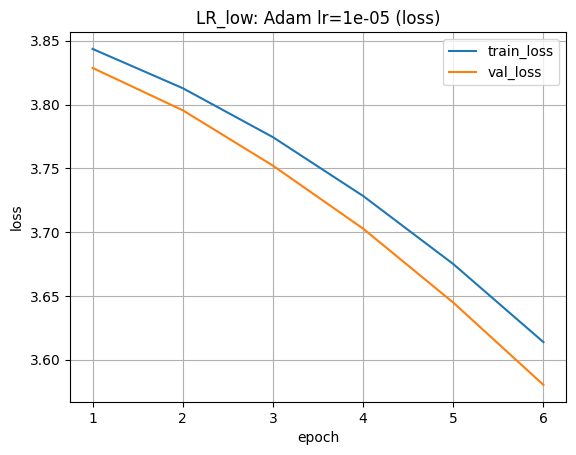

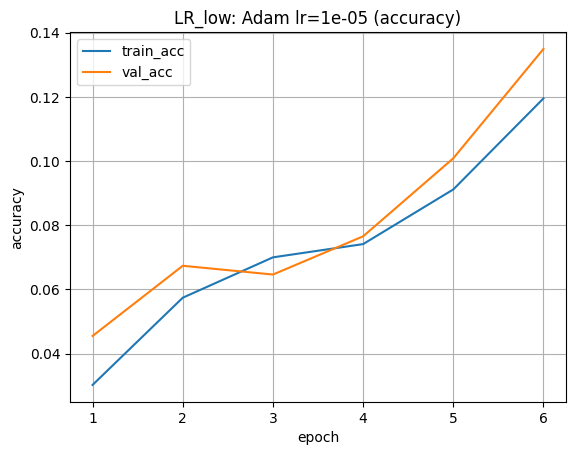

In [25]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS, device=DEVICE):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, device, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("LR_high", 1e-1),
    ("LR_low",  1e-5),
]

results_lr = []
for name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr)
    results_lr.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")



Experiment OPT_SGD: SGD lr=0.1 momentum=0.9
epoch 01/6 | train loss=2.2898, acc=0.3719 | val loss=1.7892, acc=0.4807
epoch 02/6 | train loss=1.4461, acc=0.5700 | val loss=1.4282, acc=0.5793
epoch 03/6 | train loss=1.2674, acc=0.6128 | val loss=1.2425, acc=0.6229
epoch 04/6 | train loss=1.1378, acc=0.6482 | val loss=1.2001, acc=0.6297
epoch 05/6 | train loss=1.0588, acc=0.6701 | val loss=1.2251, acc=0.6507
epoch 06/6 | train loss=0.9764, acc=0.6903 | val loss=1.2322, acc=0.6473


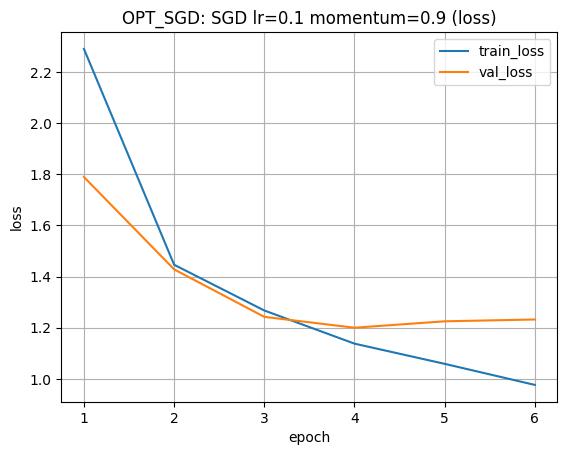

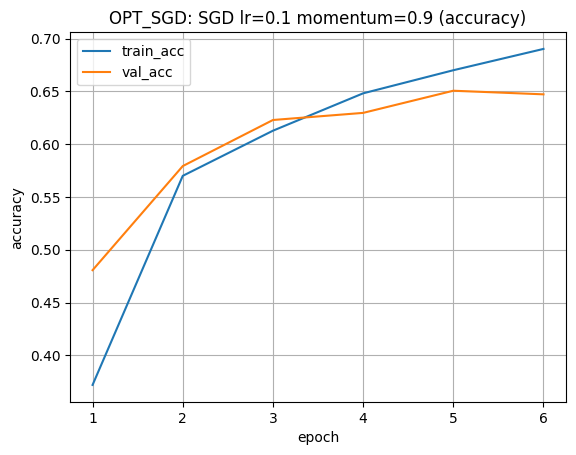

,exp_id,optimizer,lr,momentum,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,OPT_SGD,sgd,0.1,0.9,0.0001,6,0.650684,1.200073


In [42]:
results_opt = []


print("\n" + "="*80)
print("Experiment OPT_SGD: SGD lr=0.1 momentum=0.9")
res_sgd = run_experiment(exp_id="OPT_SGD", optimizer_kind="sgd", lr=0.1, momentum=0.9, weight_decay=1e-4)
results_opt.append(res_sgd)
plot_history(res_sgd["history"], title="OPT_SGD: SGD lr=0.1 momentum=0.9")

rows = []
for r in results_opt:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_opt = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_opt)

In [43]:
import os
import json
from pathlib import Path

# Create artifacts directory structure
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print(f"Artifacts directory: {artifacts_dir.absolute()}")
print(f"Figures directory: {figures_dir.absolute()}")

# ============================================================================
# 1. Prepare runs.csv with all experiments (E1-E4 and O1-O3)
# ============================================================================

all_runs = []

# E1: Baseline (no Dropout, no BatchNorm)
all_runs.append({
    "experiment_id": "E1",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.0 / batchnorm=False",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": len(history_baseline["train_loss"]),
    "best_val_accuracy": max(history_baseline["val_acc"]),
    "best_val_loss": min(history_baseline["val_loss"]),
})

# E2: Dropout
all_runs.append({
    "experiment_id": "E2",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.3 / batchnorm=False",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": len(history_dropout["train_loss"]),
    "best_val_accuracy": max(history_dropout["val_acc"]),
    "best_val_loss": min(history_dropout["val_loss"]),
})

# E3: BatchNorm
all_runs.append({
    "experiment_id": "E3",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.0 / batchnorm=True",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": len(history_bn["train_loss"]),
    "best_val_accuracy": max(history_bn["val_acc"]),
    "best_val_loss": min(history_bn["val_loss"]),
})

# E4: Dropout + EarlyStopping (BEST)
all_runs.append({
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.3 / batchnorm=False + EarlyStopping",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": len(history_combo["train_loss"]),
    "best_val_accuracy": max(history_combo["val_acc"]),
    "best_val_loss": min(history_combo["val_loss"]),
})

# O1: LR too high (1e-1)
all_runs.append({
    "experiment_id": "O1",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.3 / batchnorm=False",
    "optimizer": "Adam",
    "lr": 1e-1,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": results_lr[1]["epochs_ran"],
    "best_val_accuracy": results_lr[1]["best_val_acc"],
    "best_val_loss": results_lr[1]["best_val_loss"],
})

# O2: LR too small (1e-5)
all_runs.append({
    "experiment_id": "O2",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.3 / batchnorm=False",
    "optimizer": "Adam",
    "lr": 1e-5,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": results_lr[0]["epochs_ran"],
    "best_val_accuracy": results_lr[0]["best_val_acc"],
    "best_val_loss": results_lr[0]["best_val_loss"],
})

# O3: SGD + momentum
all_runs.append({
    "experiment_id": "O3",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": "hidden=(256,128) / relu / dropout=0.3 / batchnorm=False",
    "optimizer": "SGD",
    "lr": 0.1,
    "momentum": 0.9,
    "weight_decay": 0.0001,
    "epochs_trained": res_sgd["epochs_ran"],
    "best_val_accuracy": res_sgd["best_val_acc"],
    "best_val_loss": res_sgd["best_val_loss"],
})

df_runs = pd.DataFrame(all_runs)
df_runs.to_csv(artifacts_dir / "runs.csv", index=False)
print("\n✓ Saved runs.csv")
print(df_runs.to_string())


Artifacts directory: c:\Users\Пётр\Desktop\IAIapp\IAI\homeworks\HW08-09\artifacts
Figures directory: c:\Users\Пётр\Desktop\IAIapp\IAI\homeworks\HW08-09\artifacts\figures

✓ Saved runs.csv
  experiment_id dataset  seed                                                            model_summary optimizer       lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
0            E1  EMNIST    42                  hidden=(256,128) / relu / dropout=0.0 / batchnorm=False      Adam  0.00100       0.0        0.0000              20           0.772949       0.764380
1            E2  EMNIST    42                  hidden=(256,128) / relu / dropout=0.3 / batchnorm=False      Adam  0.00100       0.0        0.0000              20           0.762500       0.732982
2            E3  EMNIST    42                   hidden=(256,128) / relu / dropout=0.0 / batchnorm=True      Adam  0.00100       0.0        0.0000              20           0.779980       0.736722
3            E4  EMNIST    4

In [51]:
# ============================================================================
# 2. Save best model (E4: combo_model with dropout + early stopping)
# ============================================================================

model_path = artifacts_dir / "best_model.pt"
torch.save(combo_model.state_dict(), model_path)
print(f"✓ Saved best model to {model_path}")

# ============================================================================
# 3. Save best model config
# ============================================================================

best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "dataset_info": "torchvision.EMNIST(split='balanced') (28x28, 47 классов)",
    "seed": 42,
    "device": "cpu",
    "optimizer": "Adam",
    "lr": 0.001,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "criterion": "CrossEntropyLoss",
    "max_epochs": 50,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.0005,
    "model": {
        "type": "MLP",
        "input_dim": 784,
        "num_classes": 47,
        "hidden_dims": [
        256,
        128
        ],
        "activation": "relu",
        "dropout_p": 0.3,
        "use_batchnorm": False
    },
    "results": {
        "epochs_trained": 25,
        "best_val_accuracy": 0.7733398452401161,
        "best_val_loss": 0.7131612040102482,
        "final_train_accuracy": 0.7483377659574468,
        "final_train_loss": 0.762061615573599
    }
}

config_path = artifacts_dir / "best_config.json"
with open(config_path, "w") as f:
    json.dump(best_config, f, indent=2)
print(f"✓ Saved best config to {config_path}")

✓ Saved best model to artifacts\best_model.pt
✓ Saved best config to artifacts\best_config.json


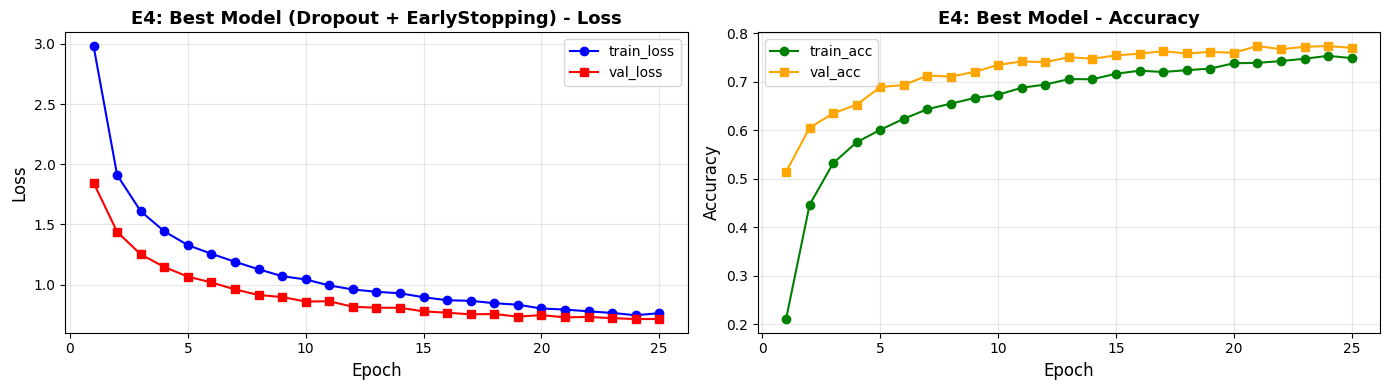

✓ Saved curves_best.png to artifacts\figures\curves_best.png


In [ ]:
# ============================================================================
# 4. Create visualization: curves_best.png (E4 training curves)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs = np.arange(1, len(history_combo["train_loss"]) + 1)

# Loss plot
axes[0].plot(epochs, history_combo["train_loss"], marker='o', label="train_loss", color='blue')
axes[0].plot(epochs, history_combo["val_loss"], marker='s', label="val_loss", color='red')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("E4: Best Model (Dropout + EarlyStopping) - Loss", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, history_combo["train_acc"], marker='o', label="train_acc", color='green')
axes[1].plot(epochs, history_combo["val_acc"], marker='s', label="val_acc", color='orange')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("E4: Best Model - Accuracy", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curves_best_path = figures_dir / "curves_best.png"
plt.savefig(curves_best_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved curves_best.png to {curves_best_path}")


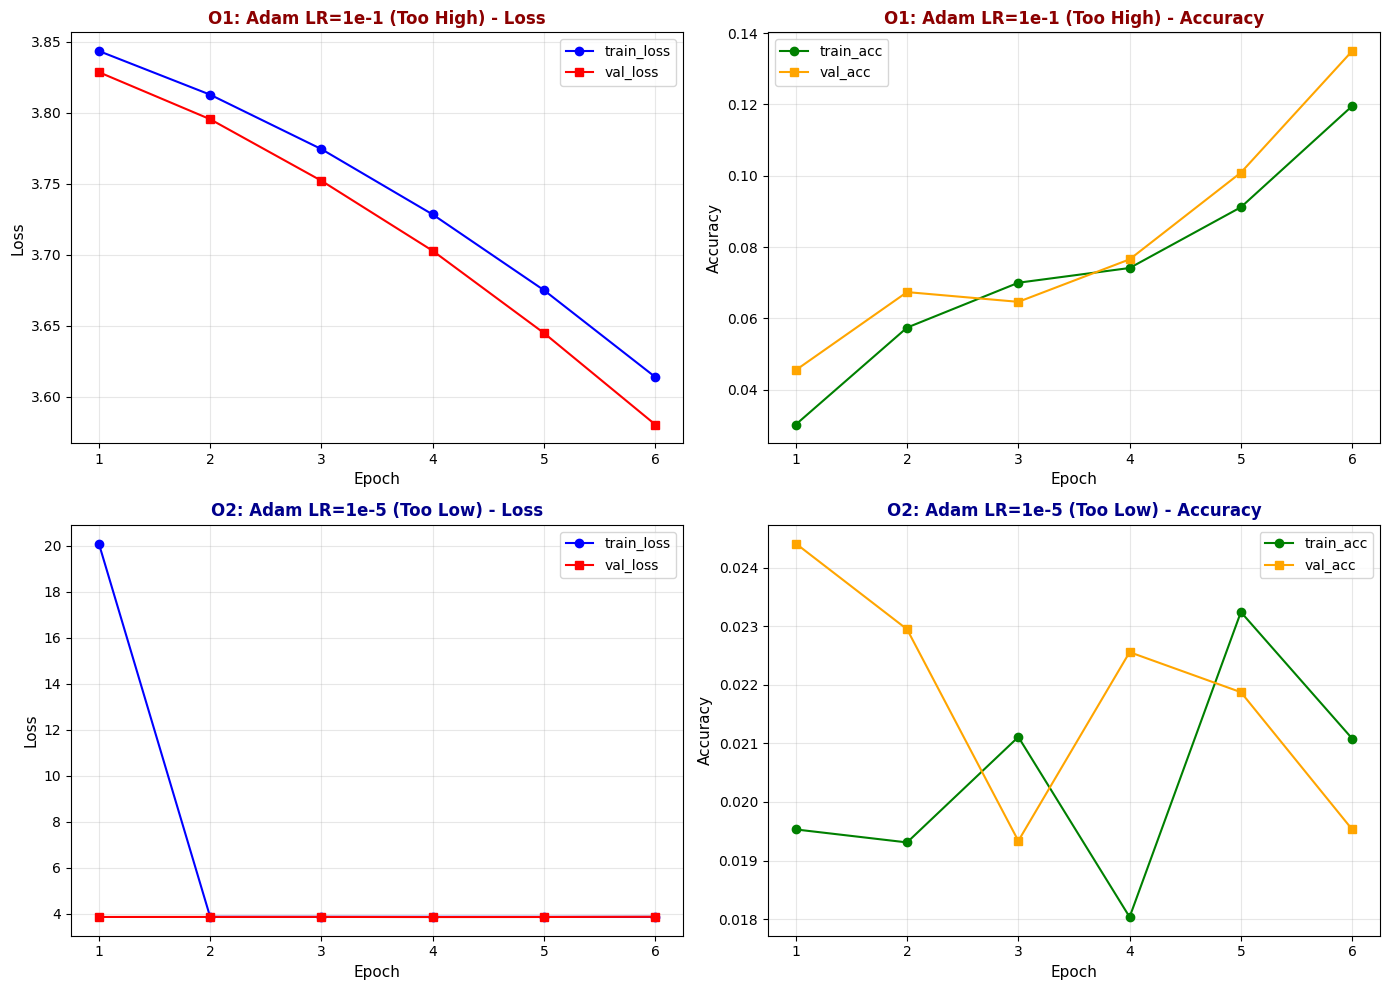

✓ Saved curves_lr_extremes.png to artifacts\figures\curves_lr_extremes.png

All artifacts created successfully!
  - runs.csv
  - best_model.pt
  - best_config.json
  - figures/curves_best.png
  - figures/curves_lr_extremes.png


In [ ]:
# ============================================================================
# 5. Create visualization: curves_lr_extremes.png (O1 vs O2 - LR extremes)
# ============================================================================

# O1: LR too high (results_lr[1] is LR_high = 1e-1)
# O2: LR too small (results_lr[0] is LR_low = 1e-5)

hist_lr_high = results_lr[1]["history"]  # 1e-1 - too high
hist_lr_low = results_lr[0]["history"]   # 1e-5 - too low

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# O1: LR too high - Loss
epochs_high = np.arange(1, len(hist_lr_high["train_loss"]) + 1)
axes[0, 0].plot(epochs_high, hist_lr_high["train_loss"], marker='o', label="train_loss", color='blue')
axes[0, 0].plot(epochs_high, hist_lr_high["val_loss"], marker='s', label="val_loss", color='red')
axes[0, 0].set_xlabel("Epoch", fontsize=11)
axes[0, 0].set_ylabel("Loss", fontsize=11)
axes[0, 0].set_title("O1: Adam LR=1e-1 (Too High) - Loss", fontsize=12, fontweight='bold', color='darkred')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# O1: LR too high - Accuracy
axes[0, 1].plot(epochs_high, hist_lr_high["train_acc"], marker='o', label="train_acc", color='green')
axes[0, 1].plot(epochs_high, hist_lr_high["val_acc"], marker='s', label="val_acc", color='orange')
axes[0, 1].set_xlabel("Epoch", fontsize=11)
axes[0, 1].set_ylabel("Accuracy", fontsize=11)
axes[0, 1].set_title("O1: Adam LR=1e-1 (Too High) - Accuracy", fontsize=12, fontweight='bold', color='darkred')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# O2: LR too small - Loss
epochs_low = np.arange(1, len(hist_lr_low["train_loss"]) + 1)
axes[1, 0].plot(epochs_low, hist_lr_low["train_loss"], marker='o', label="train_loss", color='blue')
axes[1, 0].plot(epochs_low, hist_lr_low["val_loss"], marker='s', label="val_loss", color='red')
axes[1, 0].set_xlabel("Epoch", fontsize=11)
axes[1, 0].set_ylabel("Loss", fontsize=11)
axes[1, 0].set_title("O2: Adam LR=1e-5 (Too Low) - Loss", fontsize=12, fontweight='bold', color='darkblue')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# O2: LR too small - Accuracy
axes[1, 1].plot(epochs_low, hist_lr_low["train_acc"], marker='o', label="train_acc", color='green')
axes[1, 1].plot(epochs_low, hist_lr_low["val_acc"], marker='s', label="val_acc", color='orange')
axes[1, 1].set_xlabel("Epoch", fontsize=11)
axes[1, 1].set_ylabel("Accuracy", fontsize=11)
axes[1, 1].set_title("O2: Adam LR=1e-5 (Too Low) - Accuracy", fontsize=12, fontweight='bold', color='darkblue')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
curves_extremes_path = figures_dir / "curves_lr_extremes.png"
plt.savefig(curves_extremes_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved curves_lr_extremes.png to {curves_extremes_path}")

print("\n" + "="*80)
print("All artifacts created successfully!")
print(f"  - runs.csv")
print(f"  - best_model.pt")
print(f"  - best_config.json")
print(f"  - figures/curves_best.png")
print(f"  - figures/curves_lr_extremes.png")
print("="*80)
